# Machine Learning Engineer Nanodegree
## Model Evaluation & Validation
## Project: Predicting Boston Housing Prices

This notebook is an alternative solution to the Boston Housing Price Prediction project.
The required questions, model type, evaluation metric, train/test split, cross-validation,
grid-search range, and client prediction task are all retained. The implementation and
wording are intentionally different from another solution.

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)

from sklearn.model_selection import (
    train_test_split, ShuffleSplit, learning_curve, validation_curve,
    GridSearchCV
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, make_scorer

%matplotlib inline

### Load the data

The supplied `housing.csv` file contains the three selected predictors (`RM`, `LSTAT`,
and `PTRATIO`) and the target (`MEDV`).

In [2]:
housing = pd.read_csv("housing.csv")
housing.head()

,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0


### Initial inspection

Before building a model, check the column types, dimensions, descriptive statistics,
missing values, duplicates, and unusually high/low target values.

In [3]:
print("Column types:")
print(housing.dtypes)

print("\nDataset shape:", housing.shape)

print("\nDescriptive statistics:")
display(housing.describe())

print("\nMEDV statistics:")
display(housing["MEDV"].describe())

print("\nMissing values:")
print(housing.isna().sum())

print("\nDuplicate rows:", housing.duplicated().sum())

# IQR check for MEDV
q1 = housing["MEDV"].quantile(0.25)
q3 = housing["MEDV"].quantile(0.75)
iqr = q3 - q1
low_limit = q1 - 1.5 * iqr
high_limit = q3 + 1.5 * iqr

medv_outliers = housing.loc[
    (housing["MEDV"] < low_limit) | (housing["MEDV"] > high_limit)
]

print(f"\nMEDV outliers by the 1.5×IQR rule: {len(medv_outliers)}")
print("Below lower limit:", (housing["MEDV"] < low_limit).sum())
print("Above upper limit:", (housing["MEDV"] > high_limit).sum())

Column types:
RM         float64
LSTAT      float64
PTRATIO    float64
MEDV       float64
dtype: object

Dataset shape: (489, 4)

Descriptive statistics:


,RM,LSTAT,PTRATIO,MEDV
count,489.000000,489.000000,489.000000,4.890000e+02
mean,6.240288,12.939632,18.516564,4.543429e+05
std,0.643650,7.081990,2.111268,1.653403e+05
min,3.561000,1.980000,12.600000,1.050000e+05
25%,5.880000,7.370000,17.400000,3.507000e+05
50%,6.185000,11.690000,19.100000,4.389000e+05
75%,6.575000,17.120000,20.200000,5.187000e+05
max,8.398000,37.970000,22.000000,1.024800e+06



MEDV statistics:


count    4.890000e+02
mean     4.543429e+05
std      1.653403e+05
min      1.050000e+05
25%      3.507000e+05
50%      4.389000e+05
75%      5.187000e+05
max      1.024800e+06
Name: MEDV, dtype: float64


Missing values:
RM         0
LSTAT      0
PTRATIO    0
MEDV       0
dtype: int64

Duplicate rows: 0

MEDV outliers by the 1.5×IQR rule: 22
Below lower limit: 0
Above upper limit: 22


**Observation:** The dataset has 489 observations and four numeric columns. There are no
missing values or duplicate rows. The high-side MEDV values are retained because they
represent actual observations in the supplied dataset rather than automatically being
treated as invalid data.

## Data Exploration

The prediction target is `MEDV`. The input variables are:

- `RM`: average number of rooms.
- `LSTAT`: percentage of lower-status population.
- `PTRATIO`: student-to-teacher ratio.

Separate these into a target vector and a feature table.

In [4]:
target = housing["MEDV"].copy()
X = housing.drop(columns=["MEDV"])

print(f"Number of records: {housing.shape[0]}")
print(f"Number of variables: {housing.shape[1]}")
print("Feature columns:", list(X.columns))

Number of records: 489
Number of variables: 4
Feature columns: ['RM', 'LSTAT', 'PTRATIO']


## Implementation: Calculate Statistics

In [5]:
# Required price statistics
minimum_price = target.min()
maximum_price = target.max()
mean_price = target.mean()
median_price = target.median()
mode_price = target.mode().iloc[0]
std_price = target.std(ddof=0)

stats = {
    "Minimum price": minimum_price,
    "Maximum price": maximum_price,
    "Mean price": mean_price,
    "Median price": median_price,
    "Mode price": mode_price,
    "Standard deviation": std_price
}

for label, value in stats.items():
    print(f"{label}: ${value:,.2f}")

Minimum price: $105,000.00
Maximum price: $1,024,800.00
Mean price: $454,342.94
Median price: $438,900.00
Mode price: $525,000.00
Standard deviation: $165,171.13


### Question 1 - Feature Observation

For each feature, decide whether increasing its value should generally increase or
decrease `MEDV`, and explain the intuition.

### Answer

- **RM → increase in MEDV.** More rooms usually indicate a larger home, so the expected
  selling value tends to rise.
- **LSTAT → decrease in MEDV.** A larger percentage of lower-status residents is
  associated with less expensive neighborhoods in this dataset, so MEDV tends to fall.
- **PTRATIO → decrease in MEDV.** A larger student/teacher ratio can indicate more
  crowded schools, which is generally associated with lower-valued neighborhoods.

The observed correlations support the same direction: RM is positively related to MEDV,
while LSTAT and PTRATIO are negatively related to it.

**Examples matching the intuition:**

- A house with RM = 7 would normally be expected to cost more than a similar house with RM = 6.
- A neighborhood with LSTAT = 15 would normally be expected to have higher prices than one with LSTAT = 20.
- A neighborhood with PTRATIO = 10 would normally be expected to have higher prices than one with PTRATIO = 15.

---

## Developing a Model

The next steps measure model quality, create an unseen test set, and study how a
Decision Tree behaves as its complexity changes.

## R² Score

R² measures how much of the variation in the target is explained by the predictions.
A value close to 1 is strong, while a value near 0 means the model is not explaining
much more variation than a mean prediction. R² can also be negative for a model that
performs worse than that baseline.

### Implementation: Define a Performance Metric

In [6]:
def performance_metric(y_true, y_pred):
    """Return the coefficient of determination (R²)."""
    return r2_score(y_true, y_pred)

### Question 2 - Goodness of Fit

Use the supplied five true values and predictions to calculate R². Then decide whether
the model captured the target variation successfully.

In [7]:
true_values = [3, -0.5, 2, 7, 4.2]
predicted_values = [2.5, 0.0, 2.1, 7.8, 5.3]

example_r2 = performance_metric(true_values, predicted_values)
print(f"Model R² = {example_r2:.3f}")

Model R² = 0.923


### Answer

The result is **R² ≈ 0.923**. Therefore, roughly 92% of the variation in the target is
explained by these predictions. I would consider this a successful fit for the small
example because the score is close to 1 and the predictions are generally close to the
true values.

### Implementation: Shuffle and Split Data

Use an 80/20 split. The training portion is used to learn the model, while the held-out
portion is reserved for an unbiased evaluation after training.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, target,
    test_size=0.20,
    random_state=1,
    shuffle=True
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training/testing split completed.")

Training rows: 391
Testing rows: 98
Training/testing split completed.


### Question 3 - Training and Testing

**Answer:** Splitting the data gives the learning algorithm examples for fitting and
separate examples for evaluation. This is important because a model can memorize its
training observations. Performance on the unseen test set gives a better indication of
how the model should behave on new houses. Shuffling also avoids depending on the
original row order.

---

## Analyzing Model Performance

### Learning Curves

The following function evaluates Decision Trees with maximum depths 1, 3, 6, and 10.
For each depth, both training and testing R² are shown as the amount of training data
increases.

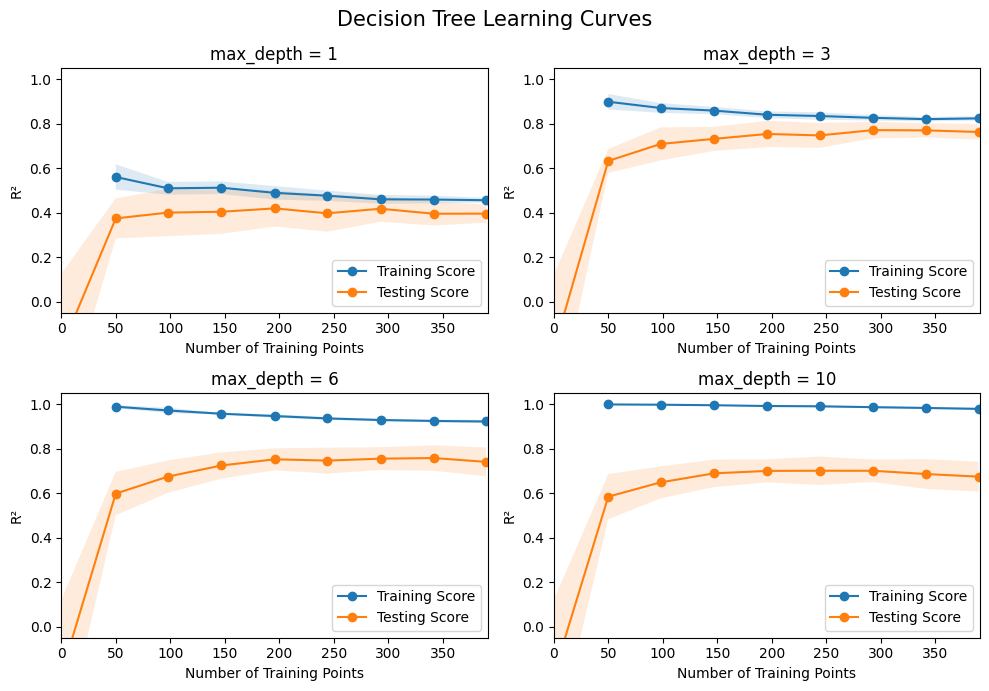

In [9]:
def show_learning_curves(X_data, y_data):
    cv = ShuffleSplit(n_splits=10, test_size=0.20, random_state=0)
    sample_sizes = np.rint(
        np.linspace(1, X_data.shape[0] * 0.8 - 1, 9)
    ).astype(int)

    fig, axes = plt.subplots(2, 2, figsize=(10, 7))

    for axis, depth in zip(axes.ravel(), [1, 3, 6, 10]):
        tree = DecisionTreeRegressor(max_depth=depth, random_state=0)

        sizes, train_scores, test_scores = learning_curve(
            tree,
            X_data,
            y_data,
            cv=cv,
            train_sizes=sample_sizes,
            scoring="r2"
        )

        train_avg = train_scores.mean(axis=1)
        test_avg = test_scores.mean(axis=1)
        train_sd = train_scores.std(axis=1)
        test_sd = test_scores.std(axis=1)

        axis.plot(sizes, train_avg, "o-", label="Training Score")
        axis.plot(sizes, test_avg, "o-", label="Testing Score")
        axis.fill_between(sizes, train_avg-train_sd, train_avg+train_sd, alpha=0.15)
        axis.fill_between(sizes, test_avg-test_sd, test_avg+test_sd, alpha=0.15)

        axis.set_title(f"max_depth = {depth}")
        axis.set_xlabel("Number of Training Points")
        axis.set_ylabel("R²")
        axis.set_xlim(0, X_data.shape[0] * 0.8)
        axis.set_ylim(-0.05, 1.05)
        axis.legend(loc="lower right")

    fig.suptitle("Decision Tree Learning Curves", fontsize=15)
    fig.tight_layout()
    plt.show()

show_learning_curves(X, target)

### Question 4 - Learning the Data

**Answer:** Consider the `max_depth = 3` graph. When the number of training examples
grows, the training score comes down from its very high small-sample value, while the
testing score rises. Eventually the two curves move closer together.

Adding more observations may improve the testing score somewhat, but the curve is
already beginning to level off. Therefore, for this model, collecting more data is
likely to provide a smaller benefit than improving the model's capacity. A depth-1
tree is mainly limited by underfitting, while a depth-10 tree shows a much larger
training/testing gap.

### Complexity Curves

Now evaluate the Decision Tree on the training data for maximum depths from 1 through
10. The validation curve helps identify underfitting, overfitting, and a useful depth.

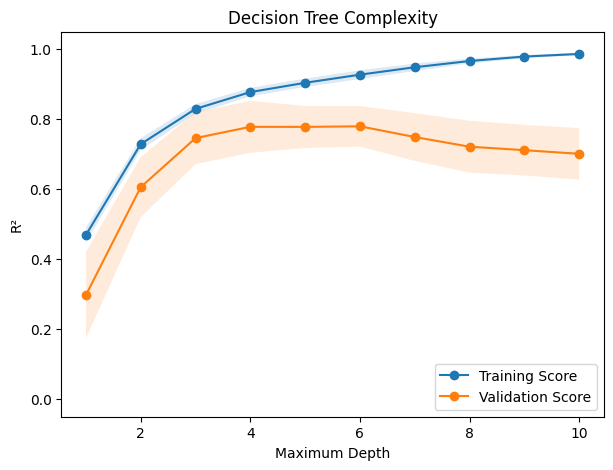

In [10]:
def show_complexity_curve(X_data, y_data):
    cv = ShuffleSplit(n_splits=10, test_size=0.20, random_state=0)
    depths = np.arange(1, 11)

    train_scores, validation_scores = validation_curve(
        DecisionTreeRegressor(random_state=0),
        X_data,
        y_data,
        param_name="max_depth",
        param_range=depths,
        cv=cv,
        scoring="r2"
    )

    train_avg = train_scores.mean(axis=1)
    validation_avg = validation_scores.mean(axis=1)
    train_sd = train_scores.std(axis=1)
    validation_sd = validation_scores.std(axis=1)

    plt.figure(figsize=(7, 5))
    plt.plot(depths, train_avg, "o-", label="Training Score")
    plt.plot(depths, validation_avg, "o-", label="Validation Score")
    plt.fill_between(depths, train_avg-train_sd, train_avg+train_sd, alpha=0.15)
    plt.fill_between(depths, validation_avg-validation_sd,
                     validation_avg+validation_sd, alpha=0.15)
    plt.xlabel("Maximum Depth")
    plt.ylabel("R²")
    plt.title("Decision Tree Complexity")
    plt.ylim(-0.05, 1.05)
    plt.legend(loc="lower right")
    plt.show()

show_complexity_curve(X_train, y_train)

### Question 5 - Bias-Variance Tradeoff

- **Depth 1 has high bias.** It is too simple, so both training and validation
  performance remain relatively low. This is the classic underfitting pattern.
- **Depth 10 has high variance.** The training score becomes extremely high while the
  validation score is noticeably lower. The widening gap is evidence that the tree is
  fitting details specific to the training data.

### Question 6 - Best-Guess Optimal Model

My best initial choice is **`max_depth = 4`**. Around this point the validation score
has reached its strong region without making the tree unnecessarily complicated.
Depths 4–6 perform very similarly, so choosing the smaller depth is a reasonable
Occam's-razor choice before running the formal grid search.

---

## Evaluating Model Performance

### Question 7 - Cross-Validation

**Answer:** In k-fold cross-validation, the training data is divided into `k` folds.
The model is trained `k` times. During each run, one fold is used for validation and
the other `k-1` folds are used for training. The final score is usually the average of
the `k` validation scores.

For grid search, this is useful because every candidate hyper-parameter setting is
evaluated across multiple partitions rather than depending on only one lucky train/
validation split. This makes the parameter selection more reliable and uses the
available training data more efficiently.

This assignment uses **ShuffleSplit** for the actual grid search: 10 randomized splits,
with 20% of the training data used as the validation portion in each split.

### Implementation: Fitting a Model

The required final model is a **DecisionTreeRegressor**. The grid searches
`max_depth` values from 1 through 10 and uses the required performance metric.

In [11]:
def fit_model(X_data, y_data):
    # 10 shuffled validation splits; each validation portion is 20%
    cv_sets = ShuffleSplit(
        n_splits=10,
        test_size=0.20,
        random_state=0
    )

    # Required decision-tree estimator
    tree_model = DecisionTreeRegressor(random_state=0)

    # Required max_depth search: 1 through 10
    search_space = {"max_depth": list(range(1, 11))}

    # Convert the project's metric into a scorer for GridSearchCV
    score_function = make_scorer(performance_metric)

    search = GridSearchCV(
        estimator=tree_model,
        param_grid=search_space,
        scoring=score_function,
        cv=cv_sets
    )

    search.fit(X_data, y_data)
    return search.best_estimator_

### Question 9 - Optimal Model

Fit the optimized tree and report its selected depth and its R² on the held-out test set.

In [12]:
optimized_tree = fit_model(X_train, y_train)

best_depth = optimized_tree.get_params()["max_depth"]
test_r2 = performance_metric(y_test, optimized_tree.predict(X_test))

print(f"Selected max_depth: {best_depth}")
print(f"Test-set R²: {test_r2:.4f}")

Selected max_depth: 6
Test-set R²: 0.7878


### Answer

The grid search selects **`max_depth = 6`**. The held-out test R² is approximately
**0.788**. This is close to the earlier guess of depth 4: the validation results around
depths 4–6 are close, but the cross-validation search selects depth 6 as the best setting
under the specified scoring procedure.

### Question 10 - Predicting Selling Prices

Use the optimized model for the three clients below.

| Feature | Client 1 | Client 2 | Client 3 |
|---|---:|---:|---:|
| Total number of rooms | 5 | 4 | 8 |
| Neighborhood poverty level (%) | 17 | 32 | 3 |
| Student-teacher ratio | 15 | 22 | 12 |

In [13]:
clients = pd.DataFrame(
    {
        "RM": [5, 4, 8],
        "LSTAT": [17, 32, 3],
        "PTRATIO": [15, 22, 12]
    },
    index=["Client 1", "Client 2", "Client 3"]
)

client_predictions = optimized_tree.predict(clients)

for client_name, predicted in zip(clients.index, client_predictions):
    print(f"{client_name}: ${predicted:,.2f}")

Client 1: $424,935.00
Client 2: $284,200.00
Client 3: $933,975.00


### Answer

| Client | Predicted selling price |
|---|---:|
| **Client 1** | **$424,935** |
| **Client 2** | **$284,200** |
| **Client 3** | **$933,975** |

These results are reasonable relative to the supplied features. Client 3 has the largest
number of rooms, the lowest LSTAT value, and the lowest PTRATIO, so it receives the
highest prediction. Client 2 has the fewest rooms, the highest LSTAT value, and the
highest PTRATIO, so it receives the lowest prediction. Client 1 lies between them.

The predictions should not be interpreted as exact market prices. A Decision Tree
produces predictions from learned regions of the training data, so the result is
dependent on the observations used to build the tree and on the selected features.

---

## Final Summary

The required workflow was completed using a Decision Tree Regressor:

1. Inspected and explored the supplied Boston housing data.
2. Identified the expected relationship between RM, LSTAT, PTRATIO and MEDV.
3. Implemented R² as the performance metric.
4. Created an 80/20 shuffled train/test split.
5. Examined learning and complexity curves.
6. Explained bias, variance, and cross-validation.
7. Used `ShuffleSplit` with 10 splits and 20% validation data.
8. Used `GridSearchCV` to search `max_depth` from 1 to 10.
9. Selected the optimized tree (`max_depth = 6`).
10. Predicted prices for the three requested clients.